In [1]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

Obraz wczytany poprawnie. Wymiary: (1697, 2434, 3)


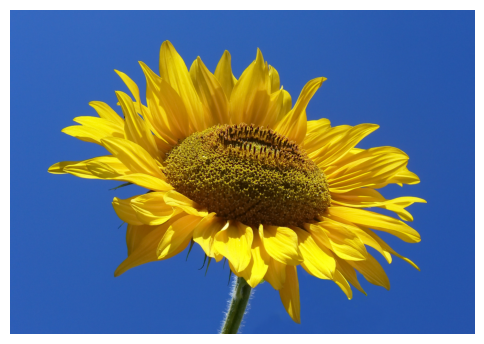

In [ ]:
image_path = 'lena.jpg'  
#image_path = 'sunflower.jpg'  
img = cv2.imread(image_path)

if img is None:
    print(f"Błąd: Nie można wczytać obrazu ze ścieżki: {image_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Obraz wczytany poprawnie. Wymiary: {img.shape}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [4]:
start = time.perf_counter()
gauss = cv2.GaussianBlur(img_rgb, (5, 5), 1.5)
czas_gauss = time.perf_counter() - start

print(f"Rozmycie Gaussa (5x5): {czas_gauss:.4f} s")

Rozmycie Gaussa (5x5): 0.0061 s


In [5]:
start = time.perf_counter()
blur = cv2.GaussianBlur(img_rgb, (5, 5), 1.5)
sharpened = cv2.addWeighted(img_rgb, 2.8, blur, -1.8, 0)
czas_wyostrzanie = time.perf_counter() - start

print(f"Wyostrzanie (5x5): {czas_wyostrzanie:.4f} s")

Wyostrzanie (5x5): 0.0111 s


In [6]:
start = time.perf_counter()
sobelx = cv2.Sobel(img_rgb, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_rgb, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobelx**2 + sobely**2)
sobel_final = np.uint8(np.clip(sobel_mag, 0, 255))
czas_sobel = time.perf_counter() - start

print(f"Detekcja krawędzi (Sobel): {czas_sobel:.4f} s")

Detekcja krawędzi (Sobel): 0.2586 s


In [7]:
start = time.perf_counter()
median = cv2.medianBlur(img_rgb, 11)
czas_mediana = time.perf_counter() - start

print(f"Filtr Medianowy (11x11): {czas_mediana:.4f} s")

Filtr Medianowy (11x11): 0.4566 s


In [8]:
kernel = np.array([[-2, -1,  0],
                   [-1,  1,  1],
                   [ 0,  1,  2]])

start = time.perf_counter()
result = cv2.filter2D(img_rgb, -1, kernel)
czas_kernel = time.perf_counter() - start

print(f"Dowolny kernel (3x3): {czas_kernel:.4f} s")

Dowolny kernel (3x3): 0.0261 s
